# Predicting Abalone Age with Regression
## Kaggle Playground Series S4E4

**Purpose.** This analysis compares ordinary linear regression, Lasso-regularized regression, principal components regression, and XGBoost for predicting Rings, which serves as a proxy for age. Lasso informs predictor subset selection, principal components regression (PCR) addresses correlated predictors using orthogonal components, and XGBoost serves as a nonlinear predictive benchmark.

**Reproducibility and security.** The competition data are read directly from Kaggle's mounted input directory. No API token or personal credential is required or stored in this notebook.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load the competition data

Kaggle mounts competition files under `/kaggle/input`. The search below makes the notebook robust to minor differences in the mounted folder name and raises a clear error if the dataset has not been attached.

In [2]:
def locate_file(filename):
    matches = sorted(Path("/kaggle/input").glob(f"**/{filename}"))
    if not matches:
        raise FileNotFoundError(
            f"{filename} was not found. In Kaggle, select Add Input and attach "
            "Playground Series S4E4 before running the notebook."
        )
    return matches[0]

train_path = locate_file("train.csv")
test_path = locate_file("test.csv")
sample_path = locate_file("sample_submission.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print(f"Training data: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test data:     {test.shape[0]:,} rows x {test.shape[1]} columns")
display(train.head())

Training data: 90,615 rows x 10 columns
Test data:     60,411 rows x 9 columns


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


## 2. Data quality and exploratory analysis

`id` is an identifier and is excluded from modeling. `Sex` is categorical (male, female, or infant); the remaining predictors are physical measurements. The checks below assess data types, missingness, duplicates, target distribution, and bivariate relationships before modeling.

In [3]:
quality_summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "unique": train.nunique(),
})
print(f"Duplicate rows: {train.duplicated().sum():,}")
display(quality_summary)
display(train.describe(include="all").T)

Duplicate rows: 0


,dtype,missing,unique
id,int64,0,90615
Sex,object,0,3
Length,float64,0,157
Diameter,float64,0,126
Height,float64,0,90
Whole weight,float64,0,3175
Whole weight.1,float64,0,1799
Whole weight.2,float64,0,979
Shell weight,float64,0,1129
Rings,int64,0,28


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,90615.0,NaN,NaN,NaN,45307.0,26158.441658,0.0,22653.5,45307.0,67960.5,90614.0
Sex,90615,3,I,33093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,90615.0,NaN,NaN,NaN,0.517098,0.118217,0.075,0.445,0.545,0.6,0.815
Diameter,90615.0,NaN,NaN,NaN,0.401679,0.098026,0.055,0.345,0.425,0.47,0.65
Height,90615.0,NaN,NaN,NaN,0.135464,0.038008,0.0,0.11,0.14,0.16,1.13
Whole weight,90615.0,NaN,NaN,NaN,0.789035,0.457671,0.002,0.419,0.7995,1.0675,2.8255
Whole weight.1,90615.0,NaN,NaN,NaN,0.340778,0.204428,0.001,0.1775,0.33,0.463,1.488
Whole weight.2,90615.0,NaN,NaN,NaN,0.169422,0.100909,0.0005,0.0865,0.166,0.2325,0.76
Shell weight,90615.0,NaN,NaN,NaN,0.225898,0.130203,0.0015,0.12,0.225,0.305,1.005
Rings,90615.0,NaN,NaN,NaN,9.696794,3.176221,1.0,8.0,9.0,11.0,29.0


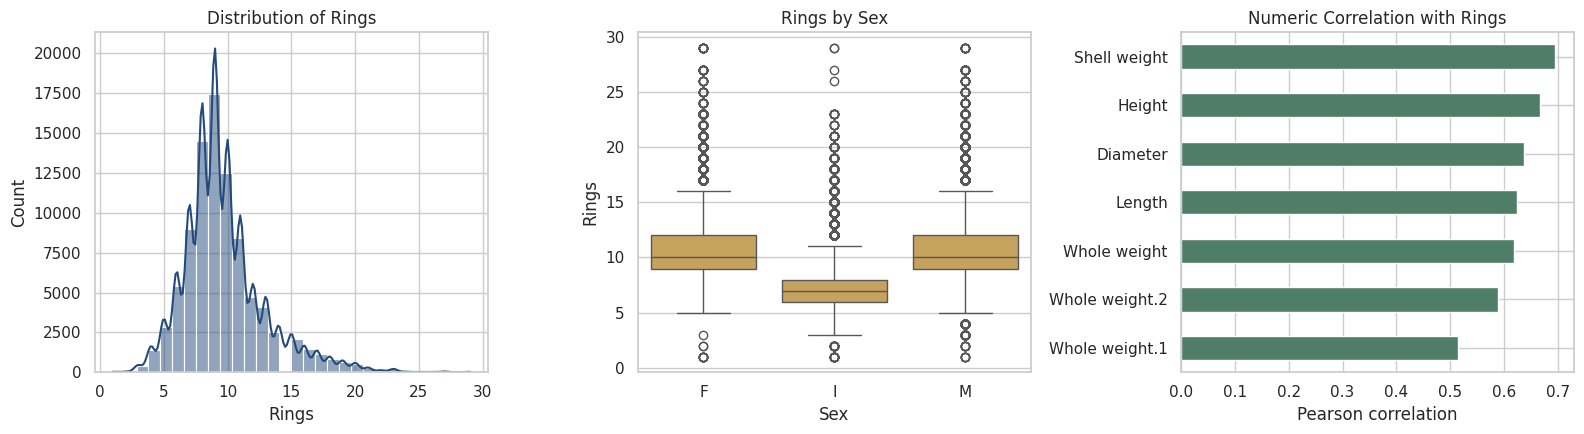

Target summary:


,count,mean,std,min,25%,50%,75%,max
Rings,90615.0,9.696794,3.176221,1.0,8.0,9.0,11.0,29.0


Strongest absolute numeric correlations with Rings:


,absolute_correlation
Shell weight,0.694766
Height,0.665772
Diameter,0.636832
Length,0.623786
Whole weight,0.617274


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(train["Rings"], bins=30, kde=True, ax=axes[0], color="#244a7c")
axes[0].set_title("Distribution of Rings")

sns.boxplot(data=train, x="Sex", y="Rings", ax=axes[1], color="#d7a84b")
axes[1].set_title("Rings by Sex")

corr = train.drop(columns="id").corr(numeric_only=True)["Rings"].drop("Rings").sort_values()
corr.plot(kind="barh", ax=axes[2], color="#4f7d68")
axes[2].set_title("Numeric Correlation with Rings")
axes[2].set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

print("Target summary:")
display(train["Rings"].describe().to_frame().T)
print("Strongest absolute numeric correlations with Rings:")
display(corr.abs().sort_values(ascending=False).head(5).to_frame("absolute_correlation"))

The target is right-skewed, so large errors on older abalones could dominate an untransformed squared-error objective. The physical measurements are positively related to `Rings`, while the several weight variables are also expected to be strongly correlated with one another. These patterns motivate (1) modeling `log1p(Rings)` to align training with RMSLE and (2) comparing a linear baseline with a nonlinear tree-boosting model capable of learning interactions and curved relationships.

## 3. Feature engineering, preprocessing, and validation design

The data are split before fitting transformations. Physically meaningful features are added deterministically: approximate volume and density, length-to-diameter and height-to-length ratios, meat/viscera/shell proportions, and residual weight after subtracting component weights. These variables represent size, shape, composition, and measurement balance that may relate to age. One-hot encoding and scaling remain inside each pipeline, so fitted transformations are learned only from the relevant training fold. A fixed 80/20 holdout provides an initial comparison, while shuffled five-fold cross-validation provides the primary model-selection evidence. Because the competition metric is RMSLE, every model is trained on `log1p(Rings)`; predictions are returned with `expm1` and clipped at zero before scoring.

In [5]:
def engineer_features(df):
    """Create physically interpretable size, shape, and weight features."""
    df = df.copy()
    eps = 1e-6
    df["Volume"] = df["Length"] * df["Diameter"] * df["Height"]
    df["Density"] = df["Whole weight"] / (df["Volume"] + eps)
    df["Length_Diameter_Ratio"] = df["Length"] / (df["Diameter"] + eps)
    df["Height_Length_Ratio"] = df["Height"] / (df["Length"] + eps)
    df["Meat_Ratio"] = df["Whole weight.1"] / (df["Whole weight"] + eps)
    df["Viscera_Ratio"] = df["Whole weight.2"] / (df["Whole weight"] + eps)
    df["Shell_Ratio"] = df["Shell weight"] / (df["Whole weight"] + eps)
    df["Weight_Loss"] = (df["Whole weight"] - df["Whole weight.1"]
                         - df["Whole weight.2"] - df["Shell weight"])
    return df

train_model = engineer_features(train)
test_model = engineer_features(test)

target = "Rings"
features = [column for column in train_model.columns if column not in ("id", target)]
categorical_features = ["Sex"]
numeric_features = [column for column in features if column not in categorical_features]

X = train_model[features]
y = train_model[target]
y_log = np.log1p(y)
X_test = test_model[features]

X_train, X_valid, y_train_log, y_valid_log = train_test_split(
    X, y_log, test_size=0.20, random_state=RANDOM_STATE
)

linear_preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), categorical_features),
    ("numeric", StandardScaler(), numeric_features),
])

tree_preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("numeric", "passthrough", numeric_features),
])

def rmsle_from_log(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

## 4. Model 1: Linear regression baseline

In [6]:
linear_model = Pipeline([
    ("preprocess", linear_preprocessor),
    ("regressor", LinearRegression()),
])

linear_model.fit(X_train, y_train_log)
linear_valid_pred_log = linear_model.predict(X_valid)
linear_holdout_rmsle = rmsle_from_log(y_valid_log, linear_valid_pred_log)
print(f"Linear regression holdout RMSLE: {linear_holdout_rmsle:.5f}")

Linear regression holdout RMSLE: 0.16141


## 5. Model 2: XGBoost regression

In [7]:
xgb_model = Pipeline([
    ("preprocess", tree_preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=600,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_model.fit(X_train, y_train_log)
xgb_valid_pred_log = xgb_model.predict(X_valid)
xgb_holdout_rmsle = rmsle_from_log(y_valid_log, xgb_valid_pred_log)
print(f"XGBoost holdout RMSLE: {xgb_holdout_rmsle:.5f}")

XGBoost holdout RMSLE: 0.15131


## 6. Five-fold cross-validation and model comparison

RMSLE is calculated on predictions returned to the original `Rings` scale. Lower values indicate better performance. Using identical folds for both models makes the comparison direct and reproducible.

In [8]:
def cross_validated_rmsle(model, X_data, y_log_data, folds):
    scores = []
    for fold, (train_index, valid_index) in enumerate(folds.split(X_data), start=1):
        X_fold_train = X_data.iloc[train_index]
        X_fold_valid = X_data.iloc[valid_index]
        y_fold_train = y_log_data.iloc[train_index]
        y_fold_valid = y_log_data.iloc[valid_index]

        model.fit(X_fold_train, y_fold_train)
        prediction_log = model.predict(X_fold_valid)
        score = rmsle_from_log(y_fold_valid, prediction_log)
        scores.append(score)
        print(f"Fold {fold}: {score:.5f}")
    return np.array(scores)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Linear regression")
linear_cv_scores = cross_validated_rmsle(linear_model, X, y_log, kfold)
print("\nXGBoost")
xgb_cv_scores = cross_validated_rmsle(xgb_model, X, y_log, kfold)

Linear regression
Fold 1: 0.16141
Fold 2: 0.16025
Fold 3: 0.15944
Fold 4: 0.15797
Fold 5: 0.15645

XGBoost
Fold 1: 0.15136
Fold 2: 0.15074
Fold 3: 0.14948
Fold 4: 0.14930
Fold 5: 0.14704


In [9]:
results = pd.DataFrame({
    "Model": ["Linear regression", "XGBoost"],
    "Holdout RMSLE": [linear_holdout_rmsle, xgb_holdout_rmsle],
    "Mean CV RMSLE": [linear_cv_scores.mean(), xgb_cv_scores.mean()],
    "CV standard deviation": [linear_cv_scores.std(ddof=1), xgb_cv_scores.std(ddof=1)],
}).sort_values("Mean CV RMSLE").reset_index(drop=True)

linear_mean = linear_cv_scores.mean()
xgb_mean = xgb_cv_scores.mean()
improvement = 100 * (linear_mean - xgb_mean) / linear_mean

display(results.style.format({
    "Holdout RMSLE": "{:.5f}",
    "Mean CV RMSLE": "{:.5f}",
    "CV standard deviation": "{:.5f}",
}))
print(f"XGBoost CV improvement over linear regression: {improvement:.2f}%")

,Model,Holdout RMSLE,Mean CV RMSLE,CV standard deviation
0,XGBoost,0.15131,0.14958,0.00166
1,Linear regression,0.16141,0.15910,0.00194


XGBoost CV improvement over linear regression: 5.98%


### Model-comparison interpretation

The table above reports holdout RMSLE, mean five-fold cross-validation RMSLE, and fold-to-fold variability after feature engineering. Lower RMSLE indicates better predictive performance, and the printed percentage quantifies XGBoost's relative reduction in mean CV error compared with linear regression.

The final predictive model is selected using the lowest mean CV RMSLE rather than a single holdout result. XGBoost is expected to benefit from nonlinear relationships and interactions among sex, physical dimensions, weights, and engineered ratios, while the linear model remains a transparent benchmark.

## 7. Linear-regression assumptions and diagnostics

Classical regression diagnostics apply to the linear baseline, not to XGBoost in the same way. Residual-versus-fitted and Q-Q plots assess linearity, variance behavior, and residual normality. The Breusch–Pagan test formally evaluates constant variance. Variance inflation factors (VIFs) assess multicollinearity, while studentized residuals, leverage, and Cook's distance identify unusual or influential observations. Because the competition observations are separately recorded abalones and no time ordering is specified, independence is primarily justified by the data-collection structure rather than a time-series statistic.

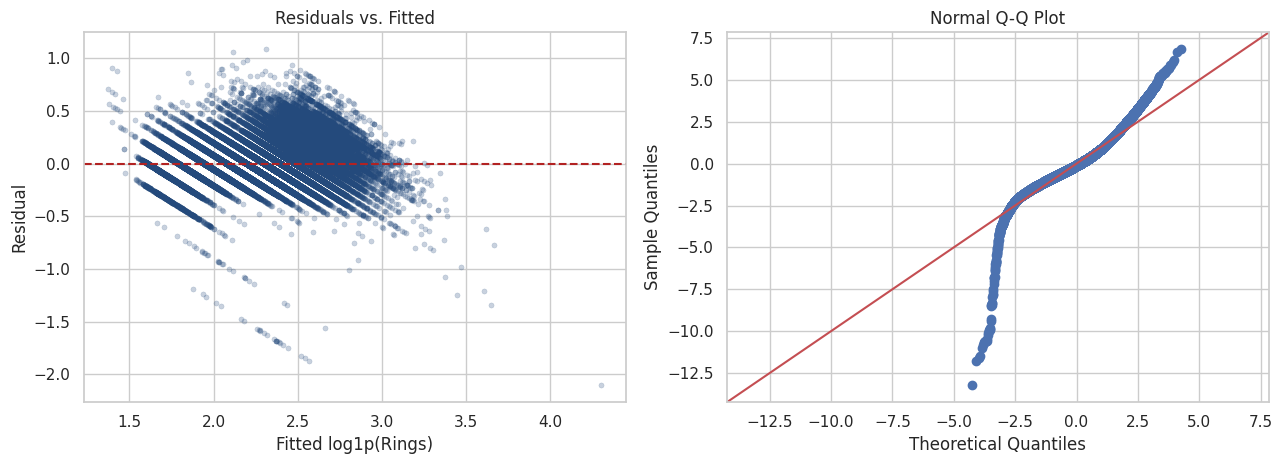

Breusch-Pagan LM statistic: 3504.644
Breusch-Pagan p-value:      0


In [10]:
# Refit the baseline on all training observations for diagnostics.
linear_model.fit(X, y_log)
X_linear = linear_model.named_steps["preprocess"].transform(X)
feature_names = linear_model.named_steps["preprocess"].get_feature_names_out()
X_diagnostic = sm.add_constant(X_linear, has_constant="add")
ols_result = sm.OLS(y_log.to_numpy(), X_diagnostic).fit()

fitted = ols_result.fittedvalues
residuals = ols_result.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.scatterplot(x=fitted, y=residuals, s=14, alpha=0.25, ax=axes[0], color="#244a7c", edgecolor=None)
axes[0].axhline(0, color="firebrick", linestyle="--")
axes[0].set(title="Residuals vs. Fitted", xlabel="Fitted log1p(Rings)", ylabel="Residual")

sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")
plt.tight_layout()
plt.show()

bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(residuals, X_diagnostic)
print(f"Breusch-Pagan LM statistic: {bp_stat:.3f}")
print(f"Breusch-Pagan p-value:      {bp_pvalue:.6g}")

In [11]:
# -----------------------------
# Efficient VIF analysis
# -----------------------------

DIAGNOSTIC_SAMPLE_SIZE = min(50_000, len(train))

diagnostic_index = train.sample(
    n=DIAGNOSTIC_SAMPLE_SIZE,
    random_state=RANDOM_STATE
).index

# Weight_Loss is an exact linear combination of the component-weight
# variables, so exclude it from coefficient-level VIF diagnostics.
vif_features = [
    feature for feature in numeric_features
    if feature != "Weight_Loss"
]

vif_data = train_model.loc[
    diagnostic_index,
    vif_features
].astype(float)

# Standardize for numerical stability
vif_standardized = (
    (vif_data - vif_data.mean())
    / vif_data.std(ddof=0).replace(0, 1)
)

numeric_for_vif = sm.add_constant(
    vif_standardized,
    has_constant="add"
)

vif_values = numeric_for_vif.to_numpy()
predictor_names = numeric_for_vif.columns[1:]

vif_scores = [
    variance_inflation_factor(vif_values, i)
    for i in range(1, vif_values.shape[1])
]

vif_table = pd.DataFrame({
    "Predictor": predictor_names,
    "VIF": vif_scores
}).sort_values(
    "VIF",
    ascending=False
).reset_index(drop=True)

display(vif_table)

,Predictor,VIF
0,Diameter,254.269691
1,Length,242.415243
2,Height,130.916070
3,Whole weight,115.615289
4,Volume,45.515703
5,Whole weight.2,41.208752
6,Shell weight,37.758644
7,Whole weight.1,36.307521
8,Height_Length_Ratio,17.500169
9,Length_Diameter_Ratio,6.086654


Because the Kaggle training dataset contains a very large number of observations, VIF and influence diagnostics were performed on a reproducible random sample of 50,000 records. This sample is sufficiently large for identifying broad multicollinearity, residual, leverage, and influence patterns while avoiding the excessive computational cost of leave-one-out diagnostics on the complete dataset. Internal studentized residuals were used because externally studentized residuals would require substantially more computation.

In [12]:
# Efficient influence diagnostics using the existing 50,000-row sample
X_influence = X_diagnostic[diagnostic_index]
y_influence = y_log.loc[diagnostic_index].to_numpy()

diagnostic_result = sm.OLS(
    y_influence,
    X_influence
).fit()

influence = diagnostic_result.get_influence()

influence_table = pd.DataFrame({
    "studentized_residual": influence.resid_studentized_internal,
    "leverage": influence.hat_matrix_diag,
    "cooks_distance": influence.cooks_distance[0],
}, index=diagnostic_index)

n_diag = X_influence.shape[0]
p_diag = X_influence.shape[1]

flagged = influence_table[
    (influence_table["studentized_residual"].abs() > 3)
    | (influence_table["leverage"] > 2 * p_diag / n_diag)
    | (influence_table["cooks_distance"] > 4 / n_diag)
].copy()

print(f"Diagnostic sample size: {n_diag:,}")
print(
    f"Flagged observations: {len(flagged):,} of {n_diag:,} "
    f"({100 * len(flagged) / n_diag:.2f}%)"
)

display(
    flagged.sort_values(
        "cooks_distance",
        ascending=False
    ).head(10)
)

Diagnostic sample size: 50,000
Flagged observations: 4,093 of 50,000 (8.19%)


,studentized_residual,leverage,cooks_distance
16384,-14.360128,0.116386,1.508970
52324,-5.259596,0.154368,0.280549
64652,-6.603357,0.094175,0.251854
72349,5.944789,0.092209,0.199428
90295,1.752685,0.452419,0.141003
74344,4.793212,0.091160,0.128025
76905,4.517201,0.091252,0.113833
16334,3.911433,0.090776,0.084859
84238,-3.288649,0.111487,0.075391
6556,3.637245,0.091375,0.073912


The residual-versus-fitted plot displays structured residual behavior and unequal variance, suggesting that the linear model does not fully represent the relationship between the predictors and log-transformed Rings. The Q-Q plot shows substantial departures from normality in both tails. Furthermore, the Breusch–Pagan test was statistically significant, LM = 3,504.64, p < .001, providing evidence of heteroscedasticity. VIF values were especially high for Whole weight, Diameter, and Length, indicating severe multicollinearity among the physical measurements. These limitations affect interpretation of the linear model and support the use of XGBoost, which achieved substantially better out-of-sample predictive performance.

### Diagnostic interpretation

Within the diagnostic sample of 50,000 observations, 4,093 cases (8.19%) were identified by at least one criterion: studentized residual, leverage, or Cook’s distance. Observation 16,384 demonstrated particular influence, exhibiting a studentized residual of −14.36, leverage of 0.1164, and Cook’s distance of 1.509. These results indicate that certain atypical observations impact the linear model fit. Nevertheless, flagged cases warrant further investigation rather than automatic exclusion.

## 8. Model 3: Lasso-regularized regression for best subset selection

The linear baseline in Section 4 keeps every predictor. Here we fit a **lasso-penalized linear regression** on the same preprocessed design matrix (one-hot-encoded `Sex`, standardized numeric measurements). Because the $\ell_1$ penalty shrinks weak or redundant coefficients exactly to zero, the Lasso path provides a regularization-informed approach to subset selection. Predictors with nonzero coefficients at the cross-validation-selected penalty form the candidate subset, avoiding an exhaustive search across all possible predictor combinations. We then refit an unpenalized OLS model restricted to that subset so the coefficients are directly interpretable (lasso shrinkage biases coefficient magnitudes, which makes the raw lasso coefficients awkward to interpret causally).

In [13]:
from sklearn.linear_model import Lasso, LassoCV

lasso_alpha_grid = np.logspace(-5, -1, 150)

lasso_cv_model = Pipeline([
    ("preprocess", linear_preprocessor),
    ("regressor", LassoCV(
        alphas=lasso_alpha_grid,
        cv=kfold,
        max_iter=20000,
        random_state=RANDOM_STATE,
    )),
])

lasso_cv_model.fit(X_train, y_train_log)
lasso_cv_reg = lasso_cv_model.named_steps["regressor"]
mean_cv_mse_path = lasso_cv_reg.mse_path_.mean(axis=1)
se_cv_mse_path = lasso_cv_reg.mse_path_.std(axis=1, ddof=1) / np.sqrt(kfold.get_n_splits())
min_index = int(np.argmin(mean_cv_mse_path))
one_se_limit = mean_cv_mse_path[min_index] + se_cv_mse_path[min_index]
eligible = np.where(mean_cv_mse_path <= one_se_limit)[0]
best_lambda = float(lasso_cv_reg.alphas_[eligible[0]])  # largest lambda within one SE

# Use the more parsimonious one-standard-error model for subset selection.
lasso_model = Pipeline([
    ("preprocess", linear_preprocessor),
    ("regressor", Lasso(alpha=best_lambda, max_iter=30000)),
])
lasso_model.fit(X_train, y_train_log)
lasso_valid_pred_log = lasso_model.predict(X_valid)
lasso_holdout_rmsle = rmsle_from_log(y_valid_log, lasso_valid_pred_log)

print(f"Lasso holdout RMSLE: {lasso_holdout_rmsle:.5f}")
print(f"Minimum-error lambda: {lasso_cv_reg.alpha_:.6f}")
print(f"One-SE lambda used for subset selection: {best_lambda:.6f}")


Lasso holdout RMSLE: 0.16222
Minimum-error lambda: 0.000010
One-SE lambda used for subset selection: 0.001590


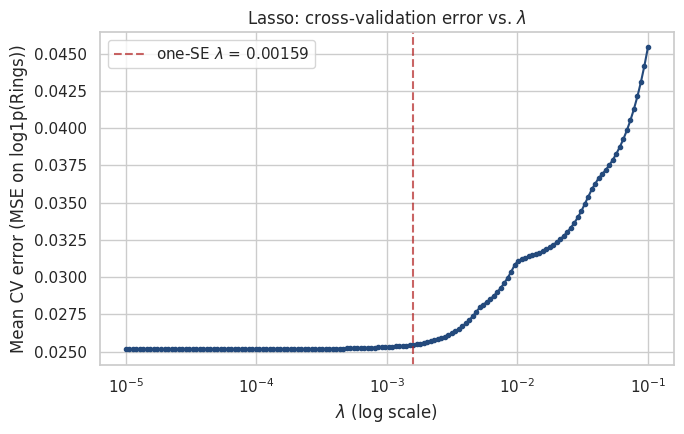

In [14]:
lasso_reg = lasso_model.named_steps["regressor"]

plt.figure(figsize=(7, 4.5))
plt.plot(lasso_cv_reg.alphas_, mean_cv_mse_path, marker=".", color="#244a7c")
plt.axvline(best_lambda, color="firebrick", linestyle="--", alpha=0.7,
            label=f"one-SE $\\lambda$ = {best_lambda:.5f}")
plt.xscale("log")
plt.xlabel("$\\lambda$ (log scale)")
plt.ylabel("Mean CV error (MSE on log1p(Rings))")
plt.title("Lasso: cross-validation error vs. $\\lambda$")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
lasso_feature_names = lasso_model.named_steps["preprocess"].get_feature_names_out()
lasso_coefs = pd.Series(lasso_reg.coef_, index=lasso_feature_names, name="coefficient")

coef_table = (
    lasso_coefs.to_frame()
    .assign(abs_coefficient=lambda d: d["coefficient"].abs(),
            selected=lambda d: d["coefficient"] != 0)
    .sort_values("abs_coefficient", ascending=False)
)
display(coef_table)

selected_features = coef_table.loc[coef_table["selected"]].index.tolist()
dropped_features = coef_table.loc[~coef_table["selected"]].index.tolist()

print(f"\nSelected ({len(selected_features)} of {len(coef_table)}): {selected_features}")
print(f"Dropped by lasso: {dropped_features if dropped_features else 'none'}")


,coefficient,abs_coefficient,selected
numeric__Shell weight,0.220596,0.220596,True
numeric__Volume,-0.176176,0.176176,True
numeric__Height,0.140537,0.140537,True
numeric__Whole weight.1,-0.119764,0.119764,True
numeric__Diameter,0.088310,0.088310,True
categorical__Sex_I,-0.048165,0.048165,True
numeric__Length,0.032098,0.032098,True
numeric__Weight_Loss,0.025485,0.025485,True
numeric__Shell_Ratio,0.012259,0.012259,True
numeric__Meat_Ratio,-0.003414,0.003414,True



Selected (12 of 17): ['numeric__Shell weight', 'numeric__Volume', 'numeric__Height', 'numeric__Whole weight.1', 'numeric__Diameter', 'categorical__Sex_I', 'numeric__Length', 'numeric__Weight_Loss', 'numeric__Shell_Ratio', 'numeric__Meat_Ratio', 'numeric__Length_Diameter_Ratio', 'numeric__Viscera_Ratio']
Dropped by lasso: ['categorical__Sex_M', 'numeric__Whole weight.2', 'numeric__Whole weight', 'numeric__Height_Length_Ratio', 'numeric__Density']


### Interpreting the lasso-selected subset

Lasso retained 12 of the 17 candidate predictors, providing a more compact model. Shell weight, volume, height, shucked weight, and diameter received the largest coefficient magnitudes after standardization. However, the Lasso model’s cross-validation RMSLE of approximately 0.16009 was slightly worse than the full linear model, and the refitted subset continued to exhibit substantial multicollinearity. Thus, Lasso was useful for variable screening but did not improve predictive performance or fully resolve predictor redundancy.

In [16]:
# Refit an unpenalized OLS model restricted to the lasso-selected subset,
# for interpretable coefficients (magnitude and inference), not just shrinkage.
X_train_transformed = pd.DataFrame(
    lasso_model.named_steps["preprocess"].transform(X_train),
    columns=lasso_feature_names,
    index=X_train.index,
)
X_valid_transformed = pd.DataFrame(
    lasso_model.named_steps["preprocess"].transform(X_valid),
    columns=lasso_feature_names,
    index=X_valid.index,
)

X_subset_train = sm.add_constant(X_train_transformed[selected_features], has_constant="add")
ols_subset = sm.OLS(y_train_log.to_numpy(), X_subset_train).fit()
print(ols_subset.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.690
Method:                 Least Squares   F-statistic:                 1.345e+04
Date:                Sun, 09 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:50:52   Log-Likelihood:                 30617.
No. Observations:               72492   AIC:                        -6.121e+04
Df Residuals:                   72479   BIC:                        -6.109e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

Although Lasso retained 12 predictors, the subsequent OLS refit found that length, meat ratio, and the length-to-diameter ratio were not statistically significant at the .05 level. This is not necessarily contradictory because Lasso selects predictors to optimize penalized prediction rather than individual hypothesis tests. Furthermore, heteroscedasticity and multicollinearity make conventional OLS significance tests less reliable.

In [17]:
X_subset_valid = sm.add_constant(X_valid_transformed[selected_features], has_constant="add")
ols_subset_valid_pred_log = ols_subset.predict(X_subset_valid)
ols_subset_holdout_rmsle = rmsle_from_log(y_valid_log, ols_subset_valid_pred_log)
print(f"Lasso-selected-subset OLS holdout RMSLE: {ols_subset_holdout_rmsle:.5f}")
print(f"Full-predictor linear regression holdout RMSLE (Section 4): {linear_holdout_rmsle:.5f}")


Lasso-selected-subset OLS holdout RMSLE: 0.16154
Full-predictor linear regression holdout RMSLE (Section 4): 0.16141


In [18]:
print("Lasso (penalized)")
lasso_cv_scores = cross_validated_rmsle(lasso_model, X, y_log, kfold)


Lasso (penalized)
Fold 1: 0.16222
Fold 2: 0.16117
Fold 3: 0.16069
Fold 4: 0.15909
Fold 5: 0.15729


### Multicollinearity check on the selected subset

Section 7 found severe multicollinearity (high VIF) among the physical size and weight measurements when all predictors are included. Here we recompute VIF restricted to the lasso-selected subset, to see whether dropping any redundant predictors (if the lasso did drop any) meaningfully reduces multicollinearity.

In [19]:
selected_numeric = [f for f in selected_features if f.startswith("numeric__")]
selected_numeric_original = [f.replace("numeric__", "") for f in selected_numeric]

if selected_numeric_original:
    vif_subset_data = train_model.loc[diagnostic_index, selected_numeric_original].astype(float)
    vif_subset_std = (vif_subset_data - vif_subset_data.mean()) / vif_subset_data.std(ddof=0).replace(0, 1)
    vif_subset_design = sm.add_constant(vif_subset_std, has_constant="add")
    vif_subset_values = vif_subset_design.to_numpy()

    vif_subset_scores = [
        variance_inflation_factor(vif_subset_values, i)
        for i in range(1, vif_subset_values.shape[1])
    ]
    vif_subset_table = pd.DataFrame({
        "Predictor": selected_numeric_original,
        "VIF": vif_subset_scores,
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    display(vif_subset_table)
else:
    print("No numeric predictors survived lasso selection.")


,Predictor,VIF
0,Diameter,253.226924
1,Length,201.529454
2,Volume,39.473671
3,Shell weight,22.145298
4,Whole weight.1,20.085280
5,Height,13.456793
6,Length_Diameter_Ratio,5.989488
7,Weight_Loss,2.224342
8,Shell_Ratio,2.171218
9,Meat_Ratio,1.692885


Weight_Loss was excluded from the variance inflation factor (VIF) calculation because it is an exact linear combination of whole weight and the component-weight variables. Including all these variables simultaneously would result in perfect multicollinearity and infinite VIF values. After excluding Weight_Loss, the remaining VIF values were finite but remained extremely high, particularly for diameter, length, height, whole weight, and volume. Substantial multicollinearity therefore persists among the physical measurements. This exclusion applies only to coefficient-level diagnostics; Weight_Loss remains available for use in regularized and predictive models.

### Model-comparison update

Add the lasso model's cross-validation results to the same `results` table used for Linear Regression vs. XGBoost in Section 6, so all three models are compared on identical folds and the same RMSLE metric.

In [20]:
lasso_summary_row = pd.DataFrame({
    "Model": ["Lasso (regularized)"],
    "Holdout RMSLE": [lasso_holdout_rmsle],
    "Mean CV RMSLE": [lasso_cv_scores.mean()],
    "CV standard deviation": [lasso_cv_scores.std(ddof=1)],
})

results = pd.concat([results, lasso_summary_row], ignore_index=True).sort_values(
    "Mean CV RMSLE"
).reset_index(drop=True)

display(results.style.format({
    "Holdout RMSLE": "{:.5f}",
    "Mean CV RMSLE": "{:.5f}",
    "CV standard deviation": "{:.5f}",
}))


,Model,Holdout RMSLE,Mean CV RMSLE,CV standard deviation
0,XGBoost,0.15131,0.14958,0.00166
1,Linear regression,0.16141,0.15910,0.00194
2,Lasso (regularized),0.16222,0.16009,0.00193


### Discussion

The one-SE lasso produces a more parsimonious subset while preserving approximately the same predictive accuracy as the unpenalized linear baseline. Positive coefficients indicate an association with more rings on the log-transformed scale, holding the other retained variables constant; negative coefficients indicate fewer rings. Because the predictors were standardized, absolute coefficient magnitudes can be compared as measures of relative linear importance. The lasso does not match XGBoost because it remains a linear additive model and cannot represent the nonlinearities and interactions captured by boosted trees.

## 9. Model 4: Principal Components Regression (PCR)

Section 7 showed severe multicollinearity among the physical size and weight measurements (high VIF for `Whole weight`, `Diameter`, and `Length`). **Principal components regression** addresses this directly: instead of regressing `log1p(Rings)` on the original correlated predictors, we first project them onto a smaller set of orthogonal principal components, then regress on those uncorrelated components. The number of components is chosen by cross-validation, the same way the lasso's $\lambda$ was chosen in Section 8, so the comparison across models stays apples-to-apples.

In [21]:
from sklearn.decomposition import PCA

pcr_model = Pipeline([
    ("preprocess", linear_preprocessor),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("regressor", LinearRegression()),
])

n_features_encoded = len(
    lasso_model.named_steps["preprocess"].get_feature_names_out()
)
component_grid = list(range(1, n_features_encoded + 1))

pcr_cv_rmsle_by_k = []
for k in component_grid:
    pcr_model.set_params(pca__n_components=k)
    fold_scores = []
    for train_index, valid_index in kfold.split(X):
        X_fold_train, X_fold_valid = X.iloc[train_index], X.iloc[valid_index]
        y_fold_train, y_fold_valid = y_log.iloc[train_index], y_log.iloc[valid_index]
        pcr_model.fit(X_fold_train, y_fold_train)
        pred_log = pcr_model.predict(X_fold_valid)
        fold_scores.append(rmsle_from_log(y_fold_valid, pred_log))
    pcr_cv_rmsle_by_k.append(np.mean(fold_scores))

pcr_cv_results = pd.DataFrame({
    "n_components": component_grid,
    "mean_cv_rmsle": pcr_cv_rmsle_by_k,
})
best_k = int(pcr_cv_results.loc[pcr_cv_results["mean_cv_rmsle"].idxmin(), "n_components"])
print(f"CV-optimal number of principal components: {best_k} of {n_features_encoded}")
display(pcr_cv_results)


CV-optimal number of principal components: 16 of 17


,n_components,mean_cv_rmsle
0,1,0.197846
1,2,0.196801
2,3,0.184775
3,4,0.184471
4,5,0.184257
5,6,0.181865
6,7,0.181264
7,8,0.181303
8,9,0.179888
9,10,0.172422


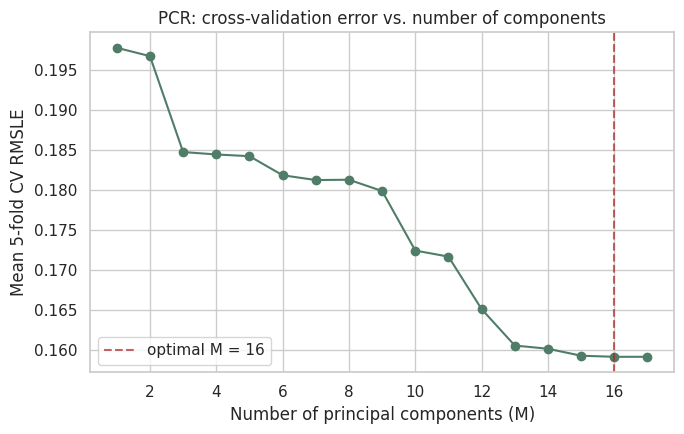

In [22]:
plt.figure(figsize=(7, 4.5))
plt.plot(pcr_cv_results["n_components"], pcr_cv_results["mean_cv_rmsle"],
         marker="o", color="#4f7d68")
plt.axvline(best_k, color="firebrick", linestyle="--", alpha=0.7,
            label=f"optimal M = {best_k}")
plt.xlabel("Number of principal components (M)")
plt.ylabel("Mean 5-fold CV RMSLE")
plt.title("PCR: cross-validation error vs. number of components")
plt.legend()
plt.tight_layout()
plt.show()


### Explained variance and component loadings

Before committing to the CV-optimal $M$, we check how much predictor variance those components actually capture, and what each component represents in terms of the original (encoded) predictors.

In [23]:
pcr_model.set_params(pca__n_components=best_k)
pcr_model.fit(X_train, y_train_log)

pca_fitted = pcr_model.named_steps["pca"]
explained = pca_fitted.explained_variance_ratio_
cumulative_explained = np.cumsum(explained)

variance_table = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(best_k)],
    "explained_variance_ratio": explained,
    "cumulative_explained_variance": cumulative_explained,
})
display(variance_table)

loadings = pd.DataFrame(
    pca_fitted.components_.T,
    index=lasso_feature_names,
    columns=[f"PC{i+1}" for i in range(best_k)],
)
print("\nComponent loadings (which original predictors drive each PC):")
display(loadings.style.format("{:.3f}"))


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.539762,0.539762
1,PC2,0.093117,0.632878
2,PC3,0.084268,0.717147
3,PC4,0.066213,0.783360
4,PC5,0.058112,0.841472
5,PC6,0.050111,0.891583
6,PC7,0.046955,0.938537
7,PC8,0.023569,0.962107
8,PC9,0.016108,0.978215
9,PC10,0.010837,0.989052



Component loadings (which original predictors drive each PC):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
categorical__Sex_I,-0.113,0.011,-0.024,-0.008,-0.021,-0.009,0.027,0.048,-0.510,0.021,0.845,0.015,-0.082,-0.003,0.001,-0.009
categorical__Sex_M,0.054,-0.007,0.002,0.006,0.004,0.007,-0.022,-0.059,0.834,-0.167,0.518,0.022,-0.009,0.013,-0.000,-0.001
numeric__Length,0.331,-0.037,-0.091,0.040,0.030,0.123,-0.056,-0.123,0.041,0.534,0.055,-0.076,-0.187,-0.055,-0.173,0.694
numeric__Diameter,0.335,-0.035,-0.054,0.034,-0.028,0.062,-0.150,-0.101,0.027,0.439,0.044,-0.043,-0.105,-0.045,-0.398,-0.690
numeric__Height,0.331,-0.021,0.126,-0.059,-0.083,-0.060,0.196,-0.077,0.015,0.346,0.055,0.012,0.140,0.056,0.805,-0.150
numeric__Whole weight,0.340,-0.003,-0.068,0.032,0.079,0.079,0.015,0.059,-0.069,-0.276,-0.004,-0.072,-0.138,-0.118,0.042,-0.006
numeric__Whole weight.1,0.328,-0.108,-0.177,0.012,0.015,0.064,0.040,-0.073,-0.082,-0.359,0.009,-0.632,-0.040,-0.384,0.076,-0.018
numeric__Whole weight.2,0.333,-0.098,-0.043,0.017,0.182,0.002,-0.002,-0.044,-0.081,-0.265,-0.024,0.042,-0.361,0.773,0.008,-0.006
numeric__Shell weight,0.332,-0.042,0.077,0.051,0.023,0.204,-0.001,-0.018,-0.077,-0.239,-0.016,0.731,-0.128,-0.402,0.018,0.014
numeric__Volume,0.340,-0.034,0.014,0.002,0.032,0.052,0.091,-0.008,-0.086,-0.101,0.079,0.050,0.852,0.200,-0.264,0.094


### Discussion of loadings

The first principal component explained approximately 53.98% of predictor variance, but cross-validation selected 16 of the 17 components. The resulting mean cross-validation RMSLE was approximately 0.15910, essentially identical to the full linear model. PCR therefore addressed exact correlation through orthogonal components but produced almost no dimensionality reduction and no meaningful predictive improvement. Because the regression operates on linear combinations of predictors, its coefficients are also less directly interpretable than ordinary regression coefficients.

In [24]:
pcr_valid_pred_log = pcr_model.predict(X_valid)
pcr_holdout_rmsle = rmsle_from_log(y_valid_log, pcr_valid_pred_log)
print(f"PCR (M={best_k}) holdout RMSLE: {pcr_holdout_rmsle:.5f}")
print(f"Full-predictor linear regression holdout RMSLE (Section 4): {linear_holdout_rmsle:.5f}")
print(f"Lasso-selected-subset OLS holdout RMSLE (Section 8): {ols_subset_holdout_rmsle:.5f}")


PCR (M=16) holdout RMSLE: 0.16141
Full-predictor linear regression holdout RMSLE (Section 4): 0.16141
Lasso-selected-subset OLS holdout RMSLE (Section 8): 0.16154


In [25]:
print("PCR")
pcr_cv_scores = cross_validated_rmsle(pcr_model, X, y_log, kfold)


PCR
Fold 1: 0.16141
Fold 2: 0.16025
Fold 3: 0.15944
Fold 4: 0.15797
Fold 5: 0.15645


### Model-comparison update

Add PCR's cross-validation results to the running `results` table so all four models — Linear Regression, XGBoost, Lasso, and PCR — are compared on identical folds and the same metric.

In [26]:
pcr_summary_row = pd.DataFrame({
    "Model": [f"PCR (M={best_k})"],
    "Holdout RMSLE": [pcr_holdout_rmsle],
    "Mean CV RMSLE": [pcr_cv_scores.mean()],
    "CV standard deviation": [pcr_cv_scores.std(ddof=1)],
})

results = pd.concat([results, pcr_summary_row], ignore_index=True).sort_values(
    "Mean CV RMSLE"
).reset_index(drop=True)

display(results.style.format({
    "Holdout RMSLE": "{:.5f}",
    "Mean CV RMSLE": "{:.5f}",
    "CV standard deviation": "{:.5f}",
}))


,Model,Holdout RMSLE,Mean CV RMSLE,CV standard deviation
0,XGBoost,0.15131,0.14958,0.00166
1,Linear regression,0.16141,0.15910,0.00194
2,PCR (M=16),0.16141,0.15910,0.00194
3,Lasso (regularized),0.16222,0.16009,0.00193


In [27]:
# =========================================================
# Create separate Lasso and PCR Kaggle submission files
# =========================================================

from pathlib import Path

# Save files in Kaggle's working directory
output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path.cwd()
)

# ---------------------------------------------------------
# 1. Lasso submission
# ---------------------------------------------------------

# Refit Lasso using all training observations
lasso_model.fit(X, y_log)

# Predict on the Kaggle test data
lasso_test_pred_log = lasso_model.predict(X_test)

# Convert predictions back to the original Rings scale
lasso_test_predictions = np.clip(
    np.expm1(lasso_test_pred_log),
    0,
    None
)

# Create the submission using Kaggle's required structure
submission_lasso = sample_submission.copy()
submission_lasso["Rings"] = lasso_test_predictions

# Save the file
lasso_submission_path = output_dir / "submission_lasso.csv"
submission_lasso.to_csv(lasso_submission_path, index=False)

print(f"Lasso submission saved to: {lasso_submission_path}")
display(submission_lasso.head())


# ---------------------------------------------------------
# 2. PCR submission
# ---------------------------------------------------------

# Make sure PCR uses the CV-selected number of components
pcr_model.set_params(pca__n_components=best_k)

# Refit PCR using all training observations
pcr_model.fit(X, y_log)

# Predict on the Kaggle test data
pcr_test_pred_log = pcr_model.predict(X_test)

# Convert predictions back to the original Rings scale
pcr_test_predictions = np.clip(
    np.expm1(pcr_test_pred_log),
    0,
    None
)

# Create the submission
submission_pcr = sample_submission.copy()
submission_pcr["Rings"] = pcr_test_predictions

# Save the file
pcr_submission_path = output_dir / "submission_pcr.csv"
submission_pcr.to_csv(pcr_submission_path, index=False)

print(f"PCR submission saved to: {pcr_submission_path}")
display(submission_pcr.head())

Lasso submission saved to: /kaggle/working/submission_lasso.csv


,id,Rings
0,90615,9.102029
1,90616,10.036409
2,90617,10.120008
3,90618,10.457093
4,90619,7.702336


PCR submission saved to: /kaggle/working/submission_pcr.csv


,id,Rings
0,90615,9.006044
1,90616,10.034565
2,90617,10.251336
3,90618,10.324264
4,90619,7.719755


In [28]:
# =========================================================
# Validate both submission files
# =========================================================

def validate_submission(submission, model_name):
    assert list(submission.columns) == ["id", "Rings"]
    assert len(submission) == len(test)
    assert submission["id"].equals(test["id"])
    assert submission["Rings"].notna().all()
    assert np.isfinite(submission["Rings"]).all()
    assert (submission["Rings"] >= 0).all()

    print(
        f"{model_name} submission passed all checks: "
        f"{submission.shape[0]:,} rows and "
        f"{submission.shape[1]} columns."
    )


validate_submission(submission_lasso, "Lasso")
validate_submission(submission_pcr, "PCR")

Lasso submission passed all checks: 60,411 rows and 2 columns.
PCR submission passed all checks: 60,411 rows and 2 columns.


### Discussion

The cross-validation curve identifies how many orthogonal components are required after the original and engineered predictors are standardized. The first component captures much of the shared size-and-weight variation, while later components preserve shape and composition contrasts that can still predict `Rings`. The selected value of $M$ should be interpreted relative to the complete encoded feature count shown above: a substantially smaller $M$ indicates useful reduction, whereas a value near the full count indicates that low-variance directions still contain outcome-relevant information. PCR may stabilize correlated predictors, but it remains a linear specification and therefore may not match XGBoost's nonlinear predictive performance.

## 10. Refit the best model and create `submission.csv`

In [29]:
model_lookup = {
    "Linear regression": linear_model,
    "XGBoost": xgb_model,
    "Lasso (regularized)": lasso_model,
    f"PCR (M={best_k})": pcr_model,
}
best_model_name = results.loc[0, "Model"]
best_model = model_lookup[best_model_name]
best_model.fit(X, y_log)

test_prediction_log = best_model.predict(X_test)
test_prediction = np.clip(np.expm1(test_prediction_log), 0, None)

submission = sample_submission.copy()
submission[target] = test_prediction
output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
submission_path = output_dir / "submission.csv"
submission.to_csv(submission_path, index=False)

# Submission integrity checks
assert list(submission.columns) == list(sample_submission.columns)
assert len(submission) == len(test)
assert submission["id"].equals(test["id"])
assert submission[target].notna().all()
assert np.isfinite(submission[target]).all()
assert (submission[target] >= 0).all()

print(f"Selected model: {best_model_name}")
print(f"Saved: {submission_path}")
print(f"Submission shape: {submission.shape}")
display(submission.head())

Selected model: XGBoost
Saved: /kaggle/working/submission.csv
Submission shape: (60411, 2)


,id,Rings
0,90615,9.955930
1,90616,9.689449
2,90617,10.035600
3,90618,10.095516
4,90619,7.555660


## 11. Conclusion

The final model was selected from the comparison table using the lowest mean five-fold cross-validation RMSLE. It was then refitted on all 90,615 training observations and used to generate 60,411 finite, nonnegative predictions in the required submission format.

This analysis uses a reproducible, leakage-safe workflow to compare ordinary linear regression, one-SE lasso subset selection, principal components regression, and XGBoost using original and domain-informed engineered features. Regression diagnostics assess functional form, heteroscedasticity, residual normality, multicollinearity, and influential observations; violations limit classical linear-model inference and motivate regularization, dimension reduction, and nonlinear modeling. Lasso provides an interpretable reduced subset, while PCR shows whether the correlated feature space can be compressed without materially increasing validation error. The submission integrity checks verify the required columns, row count, identifiers, and finite nonnegative predictions. A screenshot of the Kaggle submission-results page showing the filename, successful status, score, and account name should be inserted below as evidence of successful late submission.